In [1]:
import numpy as np
import sisl
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import plotly.graph_objects as go
from sisl import viz
from scipy.spatial import cKDTree


# Automation using `kind = 'armchair'`

In [ ]:
# ---------------------------
# Geometry helper functions
# ---------------------------

def get_coordinates(structure):
    """Return atomic coordinates as numpy array."""
    if isinstance(structure, sisl.Geometry):
        return structure.xyz
    elif isinstance(structure, np.ndarray):
        return structure
    else:
        raise TypeError("Input must be a sisl.Geometry or numpy.ndarray.")
    
def find_nearest_atoms(structure, center, n=6):
    """Return indices of n atoms closest to a given center."""
    coords = get_coordinates(structure)
    distances = np.linalg.norm(coords - center, axis=1)
    return np.argsort(distances)[:n]


def guess_hexagon_center(structure):
    """
    Try to locate the center of a hexagon near the geometric center.
    If not found, iteratively shift the center guess.
    """
    BOND = 1.42
    NN_2_DIST = 2 * BOND * np.cos(np.deg2rad(30))  # distance between two second-nearest neighbors in graphene
    RTOL = 0.05  # relative tolerance for checking if center lies on bonds
    coords = get_coordinates(structure)
    center = coords.mean(axis=0) 
    
    atom_idx = find_nearest_atoms(structure, center, n=6)
    hex_coords = coords[atom_idx]
    center = hex_coords.mean(axis=0)
    atom1, atom2 = hex_coords[[0, 1]]
    if np.isclose(atom1[1], atom2[1], rtol=RTOL) and np.isclose(atom1[1], center[1], rtol=RTOL):
        print("Warning: The geometric center lies on bonds. Trying to shift the center by half atomic distance to 2. NN.")
        print(f"{'Atom 1':>20}:", atom1)
        print(f"{'Atom 2':>20}:", atom2)
        center += np.array([0, NN_2_DIST/2, 0])  # shift the center by half the distance to the 2nd NN
        print(f"{'New Center':>20}:", center)

    return atom_idx, center


def count_removals(func):
    """Decorator to count number of atoms before and after removing overlaps."""
    def wrapper(*args, **kwargs):
        initial_count = len(args[0])
        result = func(*args, **kwargs)
        final_count = len(result)
        print(f"       Initial number of atoms: {initial_count}")
        print(f" Atoms after removing overlaps: {final_count}")
        return result
    return wrapper

# ---------------------------
# Structure generation
# ---------------------------
def find_overlap(structure, tol=0.1):
    """Find overlapping atoms in a structure."""
    coords = get_coordinates(structure)
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=tol)  # find pairs of atoms closer than `tol`
    # print(f"Found {len(pairs)} overlapping pairs of atoms.")
    return pairs

@count_removals
def delete_overlaps(structure, pairs=None):
    """Delete overlapping atoms from a structure."""
    if pairs is None:
        overlaps = find_overlap(structure)
    else:
        overlaps = pairs
    to_delete = set()
    for i, j in overlaps:
        to_delete.add(j)  # arbitrarily delete the second atom in each pair
    mask = np.array([i not in to_delete for i in range(len(structure))])
    return structure.sub(mask)

def set_index(overlaps, indexes):
    for key in indexes:
        for _, j in overlaps:
            if j in indexes[key]:
                indexes[key].remove(j)
    arm0 = len(indexes[0])
    arm1 = len(indexes[1])
    arm2 = len(indexes[2])
    indexes[1] = list(range(arm0, arm0 + arm1))
    indexes[2] = list(range(arm1, arm1 + arm2))
    return indexes


def generate_structure(width=3, length=5, bond=1.42, kind='armchair', vacuum=3.0):
    """Generate 3 rotated nanoribbons stacked around a central hexagon."""
    base = sisl.geom.graphene_nanoribbon(width=width, bond=bond, kind=kind, vacuum=vacuum)
    base = base.repeat(length, axis=0)
    
    # find central hexagon
    _, rotation_origin = guess_hexagon_center(base)
    
    # rotate and add ribbons
    structure = base.copy()
    for i in range(1, 3):
        angle = i * 60
        rotated = base.rotate(angle=angle, v=[0, 0, 1], origin=rotation_origin)
        structure += rotated
        
    overlaps = find_overlap(structure)
    indexes = {}
    for i in range(3):
        indexes[i] = list(range(i * len(base), (i + 1) * len(base)))
    if overlaps:
        indexes = set_index(overlaps, indexes)
        structure = delete_overlaps(structure, overlaps)
        return structure, indexes
    else:
        return structure, indexes


# ---------------------------
# Plotting utilities
# ---------------------------

def plot_with_center(structure, **KWARGS):
    """Plot structure and highlight central hexagon + geometric center."""
    
    KWARGS.setdefault("axes", "xy")
    KWARGS.setdefault("bind_bonds_to_ats", True)
    atom_idx, hex_center = guess_hexagon_center(structure)
    # print(f"Hexagon atom indices: {atom_idx}")
    geom_center = structure.center()

    fig = structure.plot(**KWARGS)

    # highlight hexagon atoms
    fig.update_inputs(atoms_style={"color": "red", "atoms": atom_idx.tolist()})

    # add markers
    fig.add_trace(go.Scatter(
        x=[geom_center[0]], y=[geom_center[1]],
        mode="markers", marker=dict(size=10, color="red", symbol="x"),
        name="Geometric Center"
    ))
    
    fig.add_trace(go.Scatter(
        x=[hex_center[0]], y=[hex_center[1]],
        mode="markers", marker=dict(size=10, color="blue", symbol="circle"),
        name="Rotation Center"
    ))

    return fig

WIDTH = 7
LENGTH = 8
graphene, atom_index = generate_structure(width=WIDTH, length=LENGTH)

fig = plot_with_center(graphene)

# fig.update_inputs(atoms_style=[{"color": "red", "atoms": atom_index[0]}, {"color": "blue", "atoms": atom_index[1]}, {"color": "green", "atoms": atom_index[2]} ])
fig.show()


              Atom 1: [17.04        5.18926822  1.5       ]
              Atom 2: [15.62        5.18926822  1.5       ]
          New Center: [16.33        6.41902429  1.5       ]
       Initial number of atoms: 336
 Atoms after removing overlaps: 262


## Plot DOS

       Initial number of atoms: 192
 Atoms after removing overlaps: 168


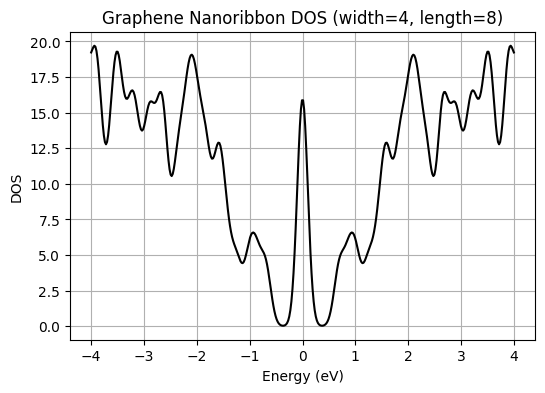

In [ ]:
def compute_dos(width=5, length=5, **kwargs):
    E = kwargs.get("E")
    k = kwargs.get("k", (0,0,0))
    graphene, _ = generate_structure(width=width, length=length)
    
    H = sisl.Hamiltonian(graphene)
    r = (0.1, 1.45)
    t = (0.0, -2.7)
    H.construct([r,t])
    # print(H)
    es = H.eigenstate(k=k)
    return es.DOS(E)

def plot_DOS(width=5, length=5, **kwargs):
    E = kwargs.get("E", None)
    
    if E is None:
        Emax = kwargs.get("Emax", 4)
        Emin = kwargs.get("Emin", -Emax)
        size = kwargs.get("size", 400)
        E = np.linspace(Emin, Emax, size)
        
    kwargs["E"] = E
    dos = compute_dos(width, length, **kwargs)
    plt.figure(figsize=(6,4))
    plt.plot(E, dos, color="black")
    plt.xlabel("Energy (eV)")
    plt.ylabel("DOS")
    plt.title(f"Graphene Nanoribbon DOS (width={width}, length={length})")
    plt.grid(True)
    plt.show()


WIDTH, LENGTH = 4, 8
plot_DOS(width=WIDTH, length=LENGTH)   

In [ ]:
interact(plot_DOS, 
         width=widgets.IntSlider(value=4, min=2, max=15, step=1, description="Width"),
         length=widgets.IntSlider(value=6, min=2, max=20, step=1, description="Length")); 

interactive(children=(IntSlider(value=4, description='Width', max=15, min=2), IntSlider(value=6, description='…